# Explainability pipeline for GPG peak prediction

This notebook perturbs one gene in one selected cell and measures how often predicted chromatin accessibility peaks change state.

The pipeline follows these ideas:

- train or load a GPG model **without wandb**
- retrieve one cell by name
- perturb one gene by name
- keep one **fixed baseline** peak prediction
- run many stochastic forward passes on the perturbed input
- compute peak-wise change frequencies
- visualize the most sensitive peaks

> **Important note**  
> In the current `GPGVAE` the decoder returns **real-valued peak scores**, not calibrated probabilities.  
> This notebook still applies your requested thresholding rule directly to those predicted peak scores:
> threshold = `0.3`, grey zone = `[0.25, 0.35]`.


## 1. Imports and project setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# --------------------------------------------------
# Update this path if your project lives somewhere else
# --------------------------------------------------
project_root = Path(r"C:\Users\user\Desktop\multiomic_vae")
dataset_name = "pbmc_10k"

# Make sure both the project package and this notebook folder are importable
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
if str(Path.cwd()) not in sys.path:
    sys.path.append(str(Path.cwd()))

%load_ext autoreload
%autoreload 2

from multiomic_vae.explainability.explainability import (
    build_gpg_model,
    detect_peak_changes,
    get_cell_vector,
    get_gene_index,
    load_pbmc_data,
    perturb_gene,
    plot_top_sensitive_peaks,
    predict_peaks,
    run_monte_carlo_perturbation,
    set_seed,
    train_gpg_without_wandb,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)

print("Project root:", project_root)
print("Dataset:", dataset_name)
print("Device:", device)


Project root: C:\Users\user\Desktop\multiomic_vae
Dataset: pbmc_10k
Device: cpu


C:\Users\user\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 2. Load gene and peak matrices
#### Using 30% of pbmc10k data

In [2]:
gene, peak, data_path = load_pbmc_data(
    project_root=project_root,
    dataset_name=dataset_name,
)

print("Data path:", data_path)
print("Gene matrix shape:", gene.shape)
print("Peak matrix shape:", peak.shape)

gene.head()


Data path: C:\Users\user\Desktop\multiomic_vae\processed_data\pbmc_10k
Gene matrix shape: (3047, 25545)
Peak matrix shape: (3047, 43788)


,AL627309.1,AL627309.5,AL627309.4,LINC01409,FAM87B,LINC01128,LINC00115,FAM41C,AL645608.6,SAMD11,...,MT-CYB,BX004987.1,AC145212.1,MAFIP,AC011043.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC007325.4
AAACAGCCACCGGCTA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,2.848636,0.0,0.0,0.0,0.0,0.0,0.000000,0.734424,0.0,0.0
AAACATGCAGGACCAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.650402,0.650402,0.0,0.0,...,2.119922,0.0,0.0,0.0,0.0,0.0,0.650402,0.650402,0.0,0.0
AAACATGCATGCATAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,2.676348,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
AAACCAACAGGTTTGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,3.111176,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
AAACCGAAGGACCGCT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,2.238282,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0


## 3. Train the model locally or load an existing checkpoint

In [3]:
import time

# Optional config override
# Set to None to use the default config from explainability.py
config_override = {
    "epochs": 30,          
    "hidden_dims": [1024], 
    "latent_dim": 256,
}

print("Training from scratch...")
print("device:", device)
print("gene shape:", gene.shape)
print("peak shape:", peak.shape)

start_total = time.time()

model, gene_x, peak_x, history = train_gpg_without_wandb(
    gene_df=gene,
    peak_df=peak,
    config=config_override,
    device=device,
    return_history=True,
    verbose=True,
    print_every=1,
)

model.eval()

print("Training finished.")
print(history.tail())
print(model)
print(f"Total elapsed: {time.time() - start_total:.2f} sec")

Training from scratch...
device: cpu
gene shape: (3047, 25545)
peak shape: (3047, 43788)
Building model...
Model built.
Device: cpu
gene_x shape: (3047, 25545)
peak_x shape: (3047, 43788)
Config: {'recon_loss': <function mse_loss at 0x00000213EBB66670>, 'hidden_dims': [1024], 'latent_dim': 256, 'activation': <class 'torch.nn.modules.activation.Tanh'>, 'lr': 0.0001, 'weight_decay': 1e-05, 'batch_size': 512, 'beta_min': 0.0, 'beta_max': 0.1, 'beta_warmup_epochs': 20, 'epochs': 30}
Starting forward pass...
Forward pass done.
gene_hat shape: (3047, 25545)
peak_hat shape: (3047, 43788)
[Epoch 1/30] loss=0.495796 | gene=0.124454 | peak=0.371343 | kl1=0.004764 | kl2=0.006197 | beta=0.000000 | time=12.12s
[Epoch 2/30] loss=0.483559 | gene=0.119309 | peak=0.364156 | kl1=0.010724 | kl2=0.008254 | beta=0.005000 | time=11.66s
[Epoch 3/30] loss=0.469691 | gene=0.112022 | peak=0.357135 | kl1=0.027735 | kl2=0.025681 | beta=0.010000 | time=13.14s
[Epoch 4/30] loss=0.452187 | gene=0.100903 | peak=0.349

## 4. Inspect available metadata

In [4]:
cell_names = gene.index.tolist()
gene_names = gene.columns.tolist()
peak_names = peak.columns.tolist()

print("Number of cells:", len(cell_names))
print("Number of genes:", len(gene_names))
print("Number of peaks:", len(peak_names))

print("\nFirst 5 cell IDs:")
print(cell_names[:5])

print("\nFirst 5 gene names:")
print(gene_names[:5])

print("\nFirst 5 peak IDs:")
print(peak_names[:5])


Number of cells: 3047
Number of genes: 25545
Number of peaks: 43788

First 5 cell IDs:
['AAACAGCCACCGGCTA-1', 'AAACATGCAGGACCAA-1', 'AAACATGCATGCATAT-1', 'AAACCAACAGGTTTGC-1', 'AAACCGAAGGACCGCT-1']

First 5 gene names:
['AL627309.1', 'AL627309.5', 'AL627309.4', 'LINC01409', 'FAM87B']

First 5 peak IDs:
['chr1:629395-630394', 'chr1:633578-634591', 'chr1:778283-779200', 'chr1:816873-817775', 'chr1:827067-827949']


## 5. Choose the cell, gene, and perturbation settings

In [5]:
#finding the cell to modify

import pandas as pd

cell_type_markers = {
    "CD4_T_cells": ["CD4", "CD3D", "IL7R", "CCR7"],
    "CD8_T_cells": ["CD8A", "CD8B", "GZMA", "PRF1"],
    "Monocytes": ["LYZ", "S100A8", "S100A9", "FCGR3A"],
    "B_cells": ["CD19", "MS4A1", "CD79A"],
    "NK_cells": ["NKG7", "GNLY", "PRF1"]
}

rows = []

for cell_type, markers in cell_type_markers.items():
    markers = [m for m in markers if m in gene.columns]
    cell_id = gene[markers].mean(axis=1).idxmax()
    rows.append({
        "cell_type": cell_type,
        "cell_id": cell_id
    })

cell_df = pd.DataFrame(rows)
cell_df

,cell_type,cell_id
0,CD4_T_cells,GTCGGTTCAGCAACAG-1
1,CD8_T_cells,AATCCGTAGCCTAATA-1
2,Monocytes,CCTAATCGTAATCGTG-1
3,B_cells,TCTTAGTTCCGCAACA-1
4,NK_cells,AATGTCCAGGTGTTAC-1


In [162]:
# --------------------------------------------------
# Edit these values for experimentation
# --------------------------------------------------
selected_cell = "TCTTAGTTCCGCAACA-1"
selected_gene = "CD79A"

# Example perturbation:
# set the selected gene expression to zero
new_gene_value = 0.0

# Monte Carlo settings
N = 100
threshold = 0.3
grey_zone = (0.25, 0.35)
min_abs_change = 0.7

print("Selected cell:", selected_cell)
print("Selected gene:", selected_gene)
print("New value:", new_gene_value)
print("N:", N)
print("Threshold:", threshold)
print("Grey zone:", grey_zone)
print("Minimum absolute change:", min_abs_change)


Selected cell: TCTTAGTTCCGCAACA-1
Selected gene: CD79A
New value: 0.0
N: 100
Threshold: 0.3
Grey zone: (0.25, 0.35)
Minimum absolute change: 0.7


## 6. Retrieve the selected cell vector and the selected gene index

In [163]:
import importlib
import multiomic_vae.explainability.explainability as explainability

importlib.reload(explainability)

from multiomic_vae.explainability.explainability import get_cell_vector, get_gene_index

In [164]:
"CCTAATCGTAATCGTG-1" in gene.index

True

In [165]:
gene_vector = get_cell_vector(
    gene_df=gene,
    cell_name=selected_cell,
    device=device,
)

gene_index = get_gene_index(
    gene_df=gene,
    gene_name=selected_gene,
)

original_gene_value = float(gene_vector[gene_index].item())

print("Gene vector shape:", tuple(gene_vector.shape))
print("Gene index:", gene_index)
print("Original selected gene value:", original_gene_value)

Gene vector shape: (25545,)
Gene index: 22561
Original selected gene value: 2.7810091972351074


## 7. Run the fixed baseline peak prediction

In [166]:
baseline_peaks = predict_peaks(
    model=model,
    gene_vector=gene_vector,
)

print("Baseline peak vector shape:", tuple(baseline_peaks.shape))
print("First 10 baseline peak predictions:")
print(baseline_peaks[:10].numpy())


Baseline peak vector shape: (43788,)
First 10 baseline peak predictions:
[ 0.35492167  0.59425277  0.9532752  -0.06142836  0.66581655 -0.08967454
  0.3680638   0.30114946  0.39247406  0.02514995]


## 8. Perturb the selected gene and run one perturbed prediction

In [167]:
perturbed_gene_vector = perturb_gene(
    gene_vector=gene_vector,
    gene_index=gene_index,
    new_value=new_gene_value,
)

perturbed_peaks_single = predict_peaks(
    model=model,
    gene_vector=perturbed_gene_vector,
)

print("Original value:", original_gene_value)
print("Perturbed value:", float(perturbed_gene_vector[gene_index].item()))
print("\nFirst 10 perturbed peak predictions:")
print(perturbed_peaks_single[:10].numpy())


Original value: 2.7810091972351074
Perturbed value: 0.0

First 10 perturbed peak predictions:
[ 0.17656797  0.43782884  0.49806568 -0.42956594  0.28811145  0.02046337
  0.31145614  0.4088013   0.4151176   0.23828155]


## 9. Detect peak state changes for this single perturbed draw

In [168]:
single_change_info = detect_peak_changes(
    baseline_peaks=baseline_peaks,
    perturbed_peaks=perturbed_peaks_single,
    threshold=threshold,
    grey_zone=grey_zone,
    min_abs_change=min_abs_change,
)

single_draw_df = pd.DataFrame(
    {
        "Peak_ID": peak_names,
        "Baseline_Prediction": single_change_info["baseline_scores"],
        "Perturbed_Prediction": single_change_info["perturbed_scores"],
        "Absolute_Delta": single_change_info["absolute_delta"],
        "Baseline_State": single_change_info["baseline_state"],
        "Perturbed_State": single_change_info["perturbed_state"],
        "Transition": single_change_info["transitions"],
        "Changed": single_change_info["changed_mask"],
    }
)

single_draw_changes = single_draw_df[single_draw_df["Changed"]].copy()
single_draw_changes.head(20)


,Peak_ID,Baseline_Prediction,Perturbed_Prediction,Absolute_Delta,Baseline_State,Perturbed_State,Transition,Changed
11,chr1:939990-940901,-0.269395,0.462200,0.731595,0,1,Closed->Open,True
27,chr1:1040406-1041304,0.705427,-0.021973,0.727400,1,0,Open->Closed,True
505,chr1:16206359-16207273,0.230596,1.047113,0.816517,0,1,Closed->Open,True
959,chr1:27631293-27632120,0.568176,-0.236983,0.805159,1,0,Open->Closed,True
1017,chr1:28326345-28327197,-0.091495,0.645011,0.736506,0,1,Closed->Open,True
1285,chr1:37682104-37682994,-0.313860,0.388810,0.702670,0,1,Closed->Open,True
1597,chr1:51170074-51170988,-0.167228,0.625972,0.793200,0,1,Closed->Open,True
1598,chr1:51175006-51175924,-0.282529,0.420088,0.702618,0,1,Closed->Open,True
1873,chr1:86395854-86396726,0.794654,0.091826,0.702829,1,0,Open->Closed,True
1929,chr1:89721088-89721974,0.357168,-0.357439,0.714607,1,0,Open->Closed,True


## 10. Run Monte Carlo perturbation with a fixed baseline

In [169]:
mc_output = run_monte_carlo_perturbation(
    model=model,
    gene_vector=gene_vector,
    gene_index=gene_index,
    new_value=new_gene_value,
    N=N,
    peak_names=peak_names,
    baseline_peaks=baseline_peaks,   # baseline stays fixed across all iterations
    threshold=threshold,
    grey_zone=grey_zone,
    min_abs_change=min_abs_change,
)

results_df = mc_output["results"]
results_df.head(40)


,Peak_ID,Change_Count,Change_Frequency,Closed_to_Open_Count,Closed_to_Open_Frequency,Open_to_Closed_Count,Open_to_Closed_Frequency,Baseline_Prediction
0,chr6:90274173-90275081,42,0.42,42,0.42,0,0.00,-0.124490
1,chr11:117989439-117990343,40,0.40,0,0.00,40,0.40,0.785905
2,chr13:52194013-52194881,38,0.38,0,0.00,38,0.38,0.838203
3,chr9:124776844-124777723,38,0.38,0,0.00,38,0.38,0.733414
4,chr12:12705636-12706487,33,0.33,0,0.00,33,0.33,0.701103
5,chr1:42657902-42658813,32,0.32,32,0.32,0,0.00,0.081248
6,chr6:43021244-43022094,32,0.32,32,0.32,0,0.00,-0.418969
7,chr6:3068395-3069196,31,0.31,31,0.31,0,0.00,-0.063244
8,chr7:90620917-90621742,31,0.31,0,0.00,31,0.31,0.612146
9,chrX:97563296-97564190,31,0.31,0,0.00,31,0.31,0.612901


## 11. Visualize the top sensitive peaks

In [170]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_top_sensitive_peaks(results_df, top_k=20, title="Top sensitive peaks"):
    df = results_df.copy()

    # --------------------------------------------------
    # Decide direction of change for each peak
    # --------------------------------------------------
    def get_direction(row):
        c2o = row["Closed_to_Open_Count"] > 0
        o2c = row["Open_to_Closed_Count"] > 0

        if c2o and not o2c:
            return "Closed → Open"
        elif o2c and not c2o:
            return "Open → Closed"
        else:
            return "Ambiguous / None"

    df["Direction"] = df.apply(get_direction, axis=1)

    # --------------------------------------------------
    # Sort by overall sensitivity
    # --------------------------------------------------
    sort_col = "Change_Frequency" if "Change_Frequency" in df.columns else "Change_Count"
    top_peaks_df = (
        df.sort_values(by=sort_col, ascending=False)
          .head(top_k)
          .copy()
    )

    # --------------------------------------------------
    # Assign colors
    # Blue  = Closed -> Open
    # Red   = Open -> Closed
    # Gray  = fallback / ambiguous
    # --------------------------------------------------
    color_map = {
        "Closed → Open": "royalblue",
        "Open → Closed": "firebrick",
        "Ambiguous / None": "gray"
    }
    top_peaks_df["Color"] = top_peaks_df["Direction"].map(color_map)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    plot_df = top_peaks_df.sort_values(by=sort_col, ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(
        plot_df["Peak_ID"].astype(str),
        plot_df[sort_col],
        color=plot_df["Color"]
    )

    plt.xlabel(sort_col.replace("_", " "))
    plt.ylabel("Peak ID")
    plt.title(title)

    legend_elements = [
        Patch(facecolor="royalblue", label="Closed → Open"),
        Patch(facecolor="firebrick", label="Open → Closed"),
        Patch(facecolor="gray", label="Ambiguous / None")
    ]
    plt.legend(handles=legend_elements)

    plt.tight_layout()
    plt.show()

    return top_peaks_df

### CD4
### 4 (1.59) → 0 (0) light turn off
#### Cell: GTCGGTTCAGCAACAG-1
#### Gene: IL7R

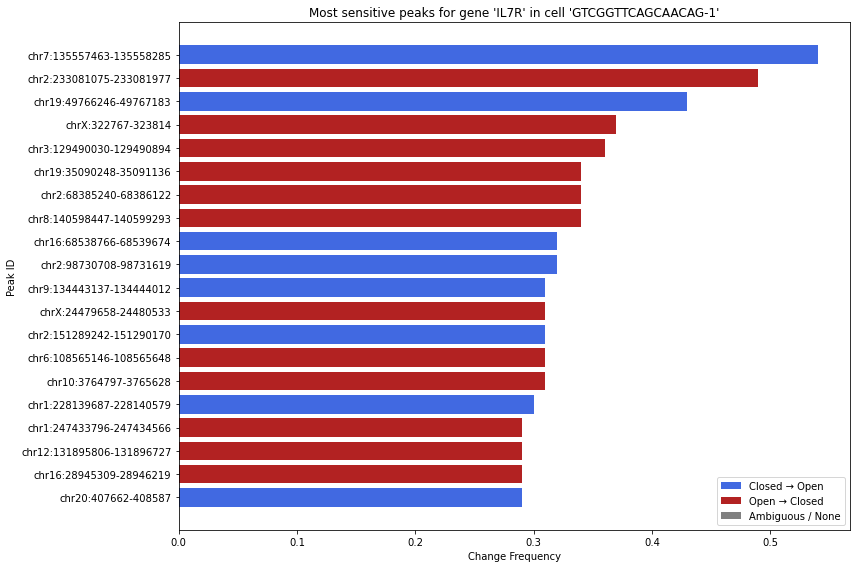

In [90]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

### CD8
### 0 (0) → 5 (1.74): light activation
#### Cell: AATCCGTAGCCTAATA-1
#### Gene: CD8B

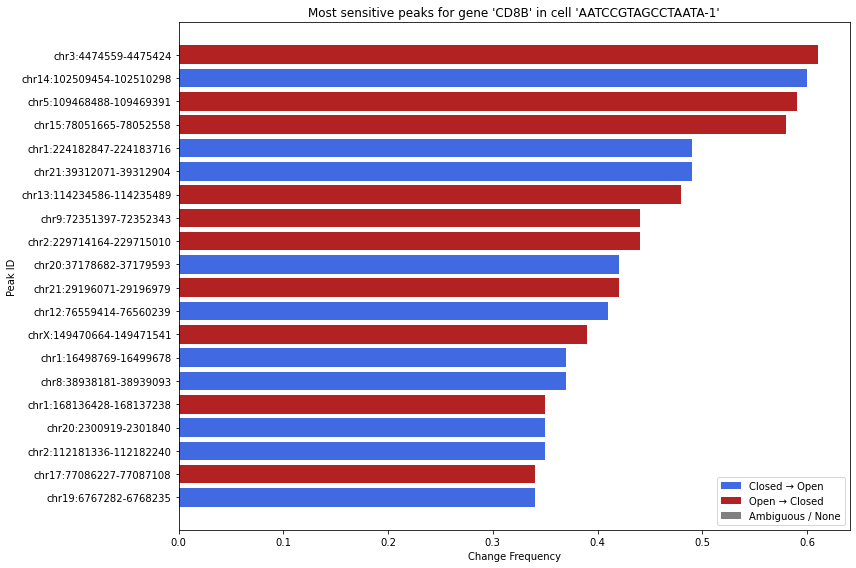

In [110]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

### Mono
### 0(0) → 20 (2.58): strong activation
#### Cell: CCTAATCGTAATCGTG-1
#### Gene: FCGR3A

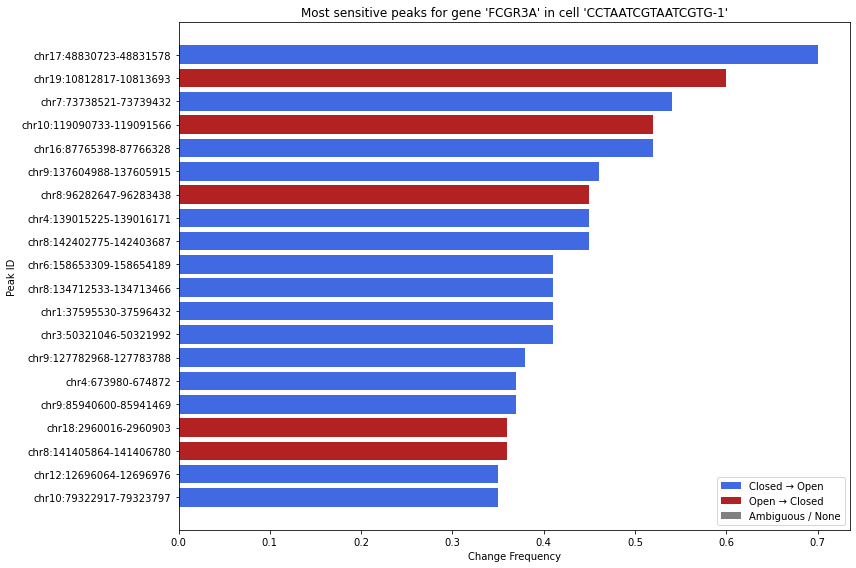

In [130]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

### B
### 17 (2.78) → 0 (0) strong turn off
#### Cell: TCTTAGTTCCGCAACA-1
#### Gene: CD79A

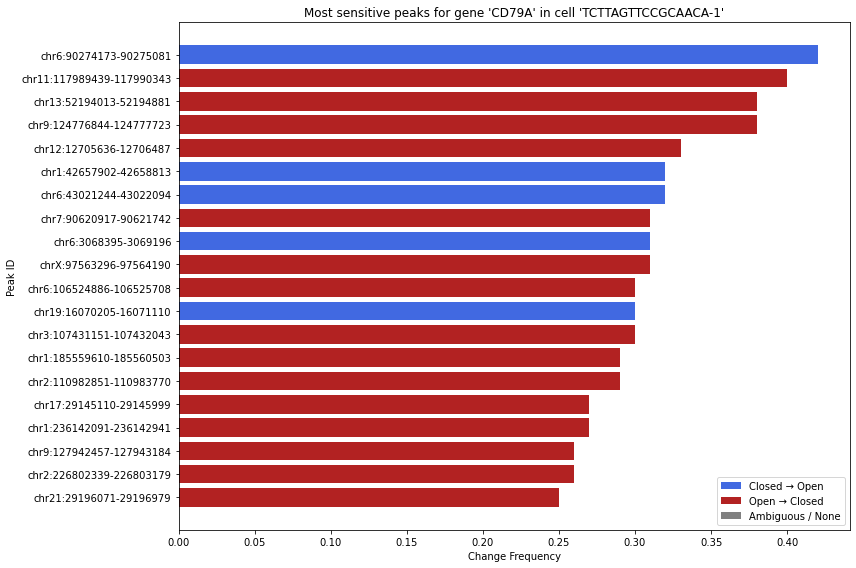

In [171]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

### NK
### 18 (3.67) → 8 (2.89) moderate decrease 
#### Cell: AATGTCCAGGTGTTAC-1
#### Gene: NKG7

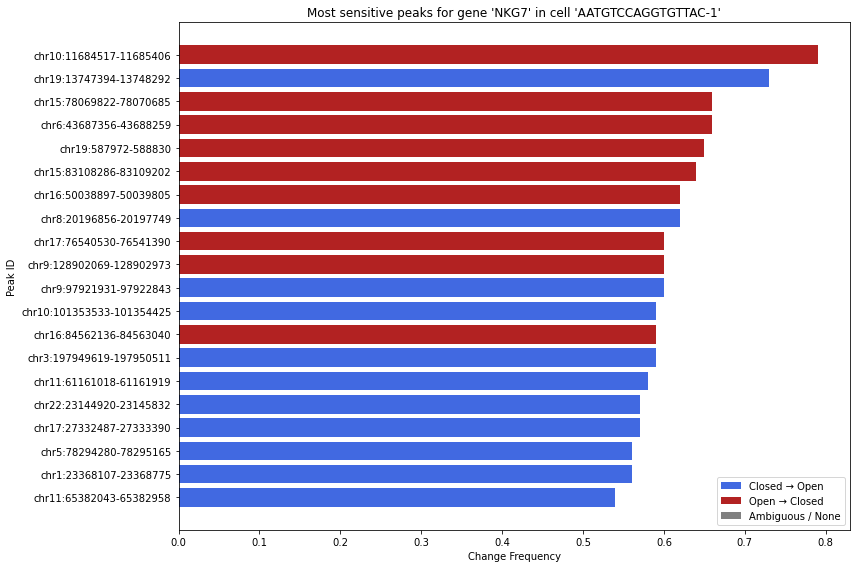

In [161]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

#### NK cells
#### selected_cell = "CATAGTCAGGCATGAA-1"
#### selected_gene = "NKG7"
#### Original value: 3.441394805908203 (9 not normalized)
#### Perturbed value: 0.0


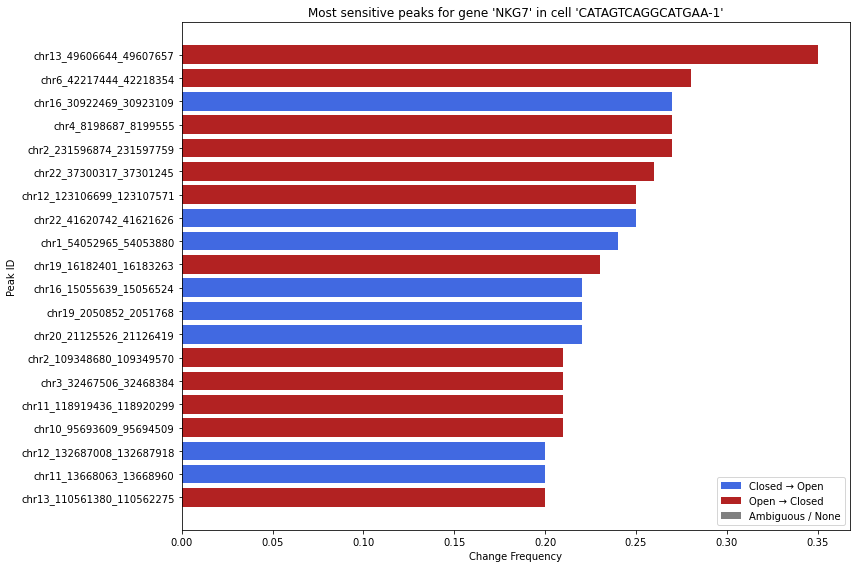

,Peak_ID,Change_Count,Change_Frequency,Closed_to_Open_Count,Closed_to_Open_Frequency,Open_to_Closed_Count,Open_to_Closed_Frequency,Baseline_Prediction,Direction,Color
0,chr13_49606644_49607657,35,0.35,0,0.00,35,0.35,0.568738,Open → Closed,firebrick
1,chr6_42217444_42218354,28,0.28,0,0.00,28,0.28,0.656387,Open → Closed,firebrick
2,chr16_30922469_30923109,27,0.27,27,0.27,0,0.00,-0.361727,Closed → Open,royalblue
4,chr4_8198687_8199555,27,0.27,0,0.00,27,0.27,0.685096,Open → Closed,firebrick
3,chr2_231596874_231597759,27,0.27,0,0.00,27,0.27,0.543074,Open → Closed,firebrick
5,chr22_37300317_37301245,26,0.26,0,0.00,26,0.26,0.628923,Open → Closed,firebrick
6,chr12_123106699_123107571,25,0.25,0,0.00,25,0.25,0.565705,Open → Closed,firebrick
7,chr22_41620742_41621626,25,0.25,25,0.25,0,0.00,-0.386601,Closed → Open,royalblue
8,chr1_54052965_54053880,24,0.24,24,0.24,0,0.00,-0.302294,Closed → Open,royalblue
9,chr19_16182401_16183263,23,0.23,0,0.00,23,0.23,0.547773,Open → Closed,firebrick


In [194]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

top_peaks_df

#### B cells
#### selected_cell = "GATGCAGCACAGGATG-1"
#### selected_gene = "CD19"
#### Original value: 1.3142046928405762 (3 not normalized)
#### Perturbed value: 1.8630841970443726  (6 not normalized)

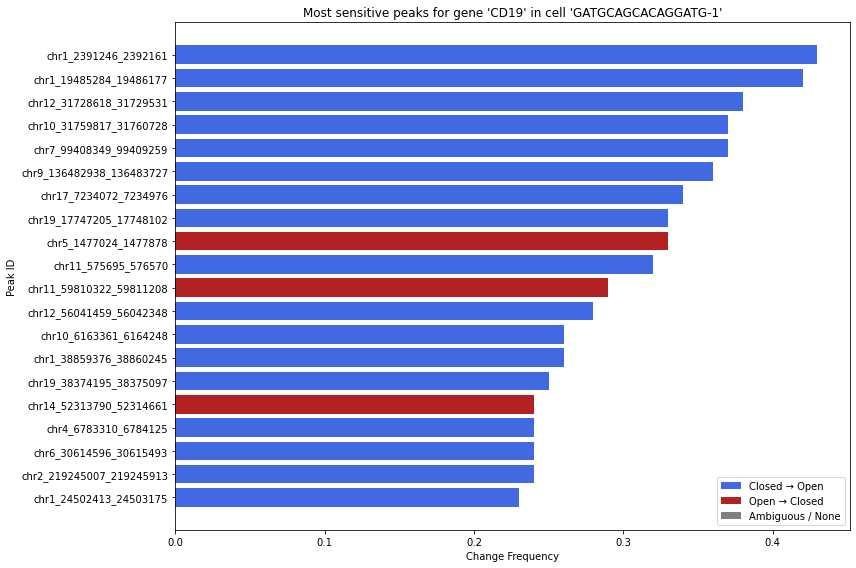

,Peak_ID,Change_Count,Change_Frequency,Closed_to_Open_Count,Closed_to_Open_Frequency,Open_to_Closed_Count,Open_to_Closed_Frequency,Baseline_Prediction,Direction,Color
0,chr1_2391246_2392161,43,0.43,43,0.43,0,0.00,-0.257109,Closed → Open,royalblue
1,chr1_19485284_19486177,42,0.42,42,0.42,0,0.00,-0.325312,Closed → Open,royalblue
2,chr12_31728618_31729531,38,0.38,38,0.38,0,0.00,-0.290431,Closed → Open,royalblue
3,chr10_31759817_31760728,37,0.37,37,0.37,0,0.00,-0.365367,Closed → Open,royalblue
4,chr7_99408349_99409259,37,0.37,37,0.37,0,0.00,-0.432226,Closed → Open,royalblue
5,chr9_136482938_136483727,36,0.36,36,0.36,0,0.00,-0.218197,Closed → Open,royalblue
6,chr17_7234072_7234976,34,0.34,34,0.34,0,0.00,-0.391002,Closed → Open,royalblue
8,chr5_1477024_1477878,33,0.33,0,0.00,33,0.33,0.672689,Open → Closed,firebrick
7,chr19_17747205_17748102,33,0.33,33,0.33,0,0.00,-0.350479,Closed → Open,royalblue
9,chr11_575695_576570,32,0.32,32,0.32,0,0.00,-0.223715,Closed → Open,royalblue


In [184]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

top_peaks_df

#### Monocytes cell: ACACAATGTTAGCGTA-1, Gene: FCGR3A 0 -> 1.582929 (5 not normalized)

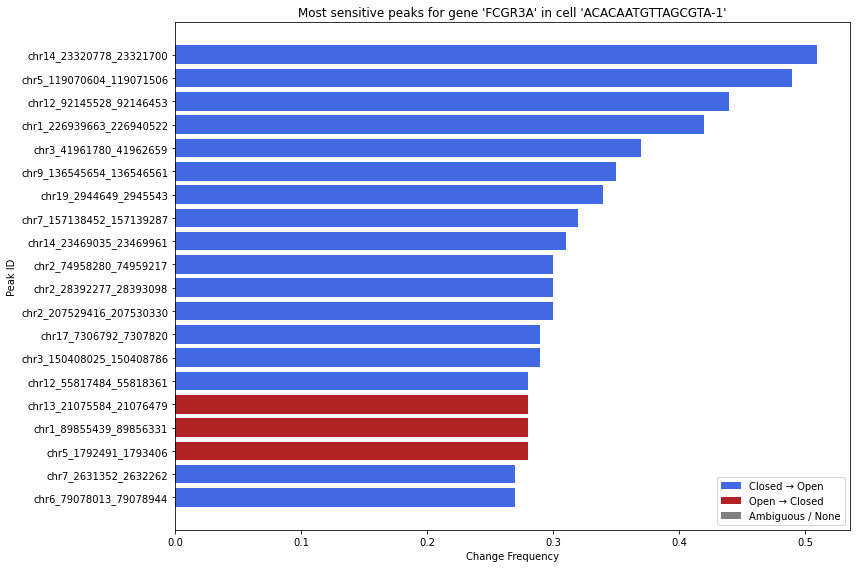

,Peak_ID,Change_Count,Change_Frequency,Closed_to_Open_Count,Closed_to_Open_Frequency,Open_to_Closed_Count,Open_to_Closed_Frequency,Baseline_Prediction,Direction,Color
0,chr14_23320778_23321700,51,0.51,51,0.51,0,0.00,-0.408099,Closed → Open,royalblue
1,chr5_119070604_119071506,49,0.49,49,0.49,0,0.00,-0.394235,Closed → Open,royalblue
2,chr12_92145528_92146453,44,0.44,44,0.44,0,0.00,-0.382204,Closed → Open,royalblue
3,chr1_226939663_226940522,42,0.42,42,0.42,0,0.00,-0.408936,Closed → Open,royalblue
4,chr3_41961780_41962659,37,0.37,37,0.37,0,0.00,-0.356056,Closed → Open,royalblue
5,chr9_136545654_136546561,35,0.35,35,0.35,0,0.00,-0.393775,Closed → Open,royalblue
6,chr19_2944649_2945543,34,0.34,34,0.34,0,0.00,-0.366889,Closed → Open,royalblue
7,chr7_157138452_157139287,32,0.32,32,0.32,0,0.00,-0.338945,Closed → Open,royalblue
8,chr14_23469035_23469961,31,0.31,31,0.31,0,0.00,-0.323159,Closed → Open,royalblue
11,chr2_74958280_74959217,30,0.30,30,0.30,0,0.00,-0.328750,Closed → Open,royalblue


In [168]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

top_peaks_df

#### CD8+ T cell: GCTTTGTGTATTTGGG-1, Gene GZMA 2.264 (10 not normalized) -> 0

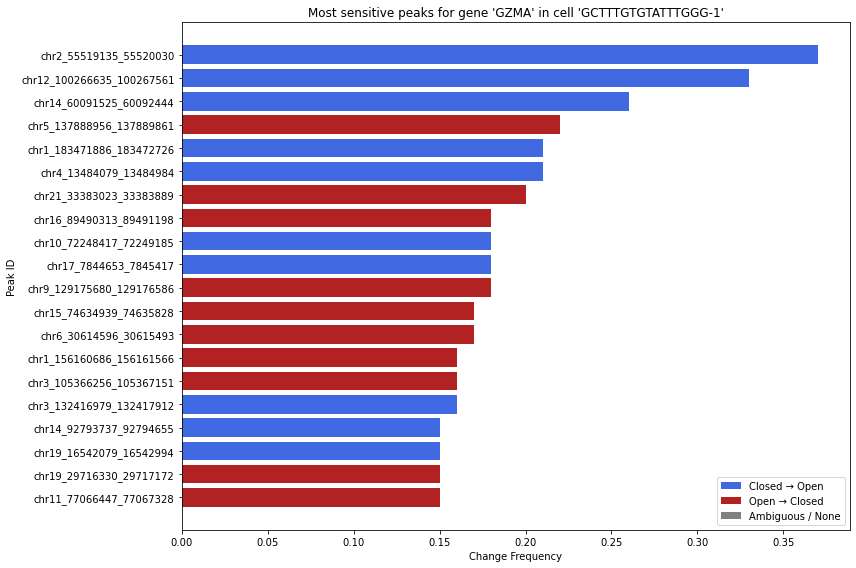

,Peak_ID,Change_Count,Change_Frequency,Closed_to_Open_Count,Closed_to_Open_Frequency,Open_to_Closed_Count,Open_to_Closed_Frequency,Baseline_Prediction,Direction,Color
0,chr2_55519135_55520030,37,0.37,37,0.37,0,0.00,-0.348559,Closed → Open,royalblue
1,chr12_100266635_100267561,33,0.33,33,0.33,0,0.00,-0.335836,Closed → Open,royalblue
2,chr14_60091525_60092444,26,0.26,26,0.26,0,0.00,-0.394083,Closed → Open,royalblue
3,chr5_137888956_137889861,22,0.22,0,0.00,22,0.22,0.633047,Open → Closed,firebrick
4,chr1_183471886_183472726,21,0.21,21,0.21,0,0.00,-0.298927,Closed → Open,royalblue
5,chr4_13484079_13484984,21,0.21,21,0.21,0,0.00,-0.301891,Closed → Open,royalblue
6,chr21_33383023_33383889,20,0.20,0,0.00,20,0.20,0.621730,Open → Closed,firebrick
7,chr10_72248417_72249185,18,0.18,18,0.18,0,0.00,-0.345730,Closed → Open,royalblue
8,chr16_89490313_89491198,18,0.18,0,0.00,18,0.18,0.833986,Open → Closed,firebrick
9,chr17_7844653_7845417,18,0.18,18,0.18,0,0.00,-0.361669,Closed → Open,royalblue


In [138]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

top_peaks_df

#### CD4+ T cell:	GTAGGTGCAAGGTGGC-1, Gene IL7R  2.75 (6 not normalized) -> 0

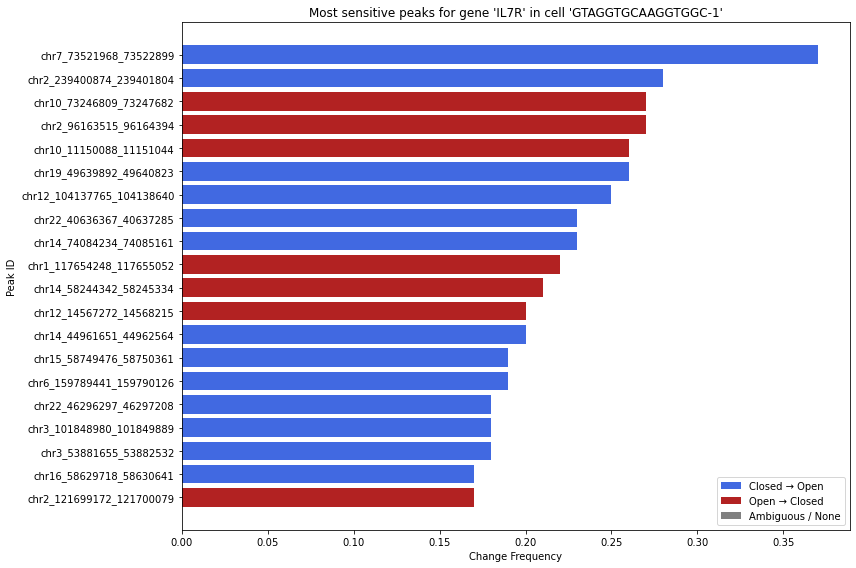

,Peak_ID,Change_Count,Change_Frequency,Closed_to_Open_Count,Closed_to_Open_Frequency,Open_to_Closed_Count,Open_to_Closed_Frequency,Baseline_Prediction,Direction,Color
0,chr7_73521968_73522899,37,0.37,37,0.37,0,0.00,-0.450649,Closed → Open,royalblue
1,chr2_239400874_239401804,28,0.28,28,0.28,0,0.00,-0.204625,Closed → Open,royalblue
2,chr10_73246809_73247682,27,0.27,0,0.00,27,0.27,0.726917,Open → Closed,firebrick
3,chr2_96163515_96164394,27,0.27,0,0.00,27,0.27,0.712077,Open → Closed,firebrick
4,chr10_11150088_11151044,26,0.26,0,0.00,26,0.26,0.620441,Open → Closed,firebrick
5,chr19_49639892_49640823,26,0.26,26,0.26,0,0.00,-0.218820,Closed → Open,royalblue
6,chr12_104137765_104138640,25,0.25,25,0.25,0,0.00,-0.420369,Closed → Open,royalblue
7,chr14_74084234_74085161,23,0.23,23,0.23,0,0.00,-0.274488,Closed → Open,royalblue
8,chr22_40636367_40637285,23,0.23,23,0.23,0,0.00,-0.224085,Closed → Open,royalblue
9,chr1_117654248_117655052,22,0.22,0,0.00,22,0.22,0.563190,Open → Closed,firebrick


In [123]:
top_peaks_df = plot_top_sensitive_peaks(
    results_df=results_df,
    top_k=20,
    title=f"Most sensitive peaks for gene '{selected_gene}' in cell '{selected_cell}'",
)

top_peaks_df